## import libraries

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

## loading model

In [2]:
model=tf.keras.models.load_model('trained_model.keras')

In [3]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 126, 126, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 63, 63, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 61, 61, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 30, 30, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 14, 14, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 6, 6, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1500)                │       3,073,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 38)                  │          57,038 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,528,288 (89.75 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 15,685,526 (59.84 MB)

In [4]:
pip install opencv-python


   ---------------------------------------- 0.0/38.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.8 MB ? eta -:--:--
    --------------------------------------- 0.5/38.8 MB 2.1 MB/s eta 0:00:19
    --------------------------------------- 0.8/38.8 MB 2.4 MB/s eta 0:00:16
   - -------------------------------------- 1.0/38.8 MB 1.7 MB/s eta 0:00:22
   - -------------------------------------- 1.6/38.8 MB 2.0 MB/s eta 0:00:19
   - -------------------------------------- 1.8/38.8 MB 1.8 MB/s eta 0:00:21
   -- ------------------------------------- 2.4/38.8 MB 1.8 MB/s eta 0:00:21
   -- ------------------------------------- 2.9/38.8 MB 1.9 MB/s eta 0:00:20
   --- ------------------------------------ 3.4/38.8 MB 2.0 MB/s eta 0:00:18
   --- ------------------------------------ 3.7/38.8 MB 1.9 MB/s eta 0:00:19
   ---- ----------------------------------- 4.2/38.8 MB 2.0 MB/s eta 0:00:18
   ---- ----------------------------------- 4.7/38.8 MB 2.0 MB/s eta 0:00:18
   ----- ---

In [6]:
import os
print(os.path.isfile("test/AppleCedarRust4.JPG"))

True


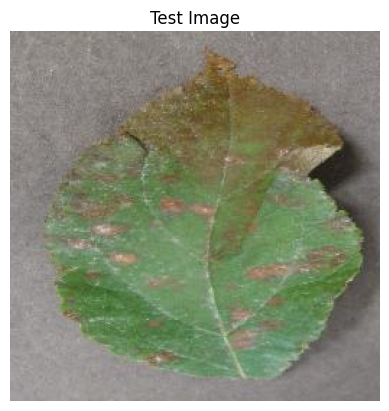

In [8]:
import cv2
import matplotlib.pyplot as plt

image_path = r'test/AppleCedarRust4.JPG'
# Reading an image in default mode
img = cv2.imread(image_path)

if img is None:
    print("Error: Image not found or unable to load.")
else:
    # Convert BGR to RGB if image is loaded successfully
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Displaying the image
    plt.imshow(img)
    plt.title('Test Image')
    plt.axis('off')
    plt.show()


## Testing Model

In [9]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128,128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])  # Convert single image to a batch.
print(input_arr.shape)

(1, 128, 128, 3)


In [10]:
prediction=model.predict(input_arr)
prediction,prediction.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step


(array([[1.7995106e-08, 7.5980923e-11, 9.9984753e-01, 8.3193367e-14,
         1.4747528e-12, 2.2366494e-05, 1.0726585e-13, 6.3138177e-05,
         1.3735575e-11, 3.8912580e-07, 5.2447865e-15, 1.2489400e-07,
         2.2625576e-08, 9.8720483e-11, 3.0961431e-12, 1.5014101e-11,
         4.0323794e-06, 3.6650942e-13, 3.7040144e-07, 1.5754764e-11,
         2.3417065e-11, 8.6029170e-12, 2.9181553e-11, 5.9127148e-12,
         9.5319900e-16, 1.1787374e-08, 3.5490202e-09, 6.1025431e-13,
         4.0300140e-05, 1.0364558e-07, 2.1203328e-05, 8.4587488e-14,
         3.2652980e-07, 3.4156881e-14, 5.9165763e-11, 3.9572417e-12,
         6.1283704e-12, 3.0923028e-11]], dtype=float32),
 (1, 38))

In [11]:
result_index = np.argmax(prediction).
result_index

np.int64(2)

In [12]:
class_name=['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

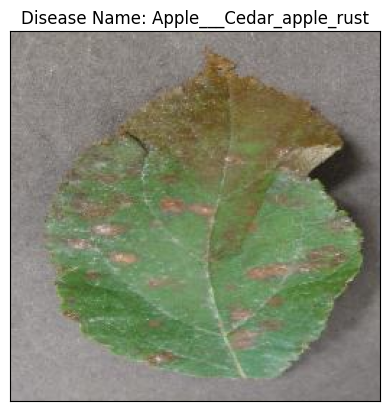

In [13]:
# Displaying the disease prediction
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"Disease Name: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()

In [14]:
model_prediction

'Apple___Cedar_apple_rust'